In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
mu_0 = 4 * np.pi * 1e-7
epsilon_0 = 8.854187817e-12


In [2]:
# . . Definitions of wavenumber components and approximations

def k_r_func(sigma, mu, epsilon, omega):
    R = sigma / (epsilon * omega)
    return omega * np.sqrt(mu * epsilon) * np.sqrt((np.sqrt(1 + R**2) + 1) / 2)


def k_i_func(sigma, mu, epsilon, omega):
    R = sigma / (epsilon * omega)
    return omega * np.sqrt(mu * epsilon) * np.sqrt((np.sqrt(1 + R**2) - 1) / 2)


def k_quasi_func(sigma, mu, epsilon, omega):
    return np.sqrt(mu * sigma * omega / 2)


def k_r_wave_func(sigma, mu, epsilon, omega):
    return omega * np.sqrt(mu * epsilon)


def k_i_wave_func(sigma, mu, epsilon, omega):
    return (sigma / 2) * np.sqrt(mu / epsilon)


In [3]:
# Generate your array of ratios as suggested:
ratios = np.logspace(-3, 3)

# Set the physical parameters from the question:
sigma = 0.01
epsilon = epsilon_0
mu = mu_0


In [4]:
# . . Calculate omega
omega = sigma / (epsilon * ratios)


In [5]:
# . . Call the full wavenumber functions:
k_r = k_r_func(sigma, mu, epsilon, omega)
k_i = k_i_func(sigma, mu, epsilon, omega)

# . . Quasi-static approximation
k_quasi = k_quasi_func(sigma, mu, epsilon, omega)

# . . Wave approximation
k_r_wave = k_r_wave_func(sigma, mu, epsilon, omega)
k_i_wave = k_i_wave_func(sigma, mu, epsilon, omega) * np.ones_like(ratios)


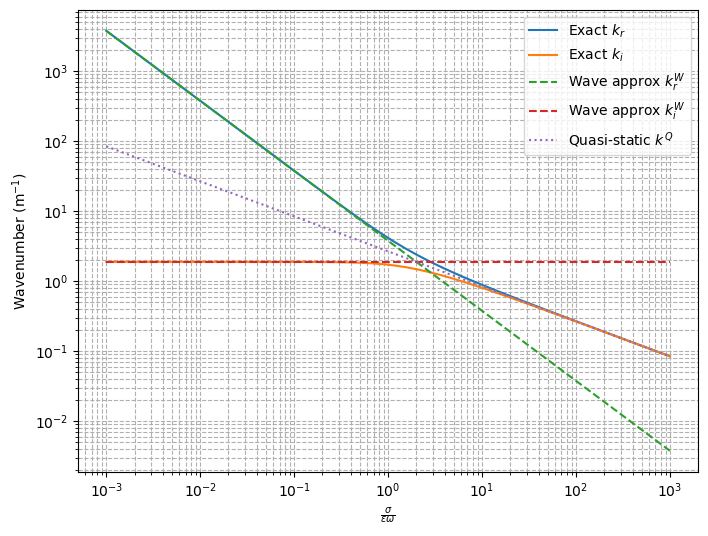

In [6]:
# . . Plotting section
plt.figure(figsize=(8,6))

plt.loglog(ratios, k_r, label=r'Exact $k_r$')
plt.loglog(ratios, k_i, label=r'Exact $k_i$')

plt.loglog(ratios, k_r_wave, '--', label=r'Wave approx $k_r^W$')
plt.loglog(ratios, k_i_wave, '--', label=r'Wave approx $k_i^W$')

plt.loglog(ratios, k_quasi, ':', label=r'Quasi-static $k^Q$')

# . . Label axes and show legend
plt.xlabel(r'$\frac{\sigma}{\epsilon\omega}$')
plt.ylabel(r'Wavenumber (m$^{-1}$)')
plt.legend()
plt.grid(True, which='both', ls='--')

plt.show()
